In [1]:
pip install transformers datasets evaluate accelerate scikit-learn pandas

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)

# 1. LOAD DATA

train_path = "train.csv"
val_path = "val.csv"
test_path = "test.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print(train_df["label"].value_counts())

# 2. CHUẨN HOÁ CỘT DỮ LIỆU

def prepare_df(df):
    df = df.copy()

    df["text"] = df["text"].astype(str).fillna("")
    df["label"] = df["label"].astype(str).str.upper().str.strip()

    label2id = {
        "REAL": 0,
        "FAKE": 1
    }

    df = df[df["label"].isin(label2id.keys())]
    df["labels"] = df["label"].map(label2id).astype(int)

    return df[["text", "labels"]]

train_df = prepare_df(train_df)
val_df = prepare_df(val_df)
test_df = prepare_df(test_df)

print("Sau xử lý:")
print(train_df.head())


Train: (10417, 18)
Val: (2232, 18)
Test: (2233, 18)
label
REAL    6747
FAKE    3670
Name: count, dtype: int64
Sau xử lý:
                                                text  labels
0  6 gương mặt sáng giá cho giải 'Nobel Toán học'...       0
1  Ăn mặc thế nào mới có thể tiếp thụ năng lượng...       1
2  Chướng bụng đầy hơi: Nguyên nhân, triệu chứng ...       0
3  COVID-19 và Khoa học về khoảng cách xã hội nhữ...       0
4  Nhiều phố trung tâm Đà Nẵng ngập sau mưa lớn đ...       0


In [3]:
# 3. CONVERT

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

In [4]:
# 4. TOKENIZER

model_name = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

MAX_LENGTH = 256

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
val_dataset = val_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/10417 [00:00<?, ? examples/s]

Map:   0%|          | 0/2232 [00:00<?, ? examples/s]

Map:   0%|          | 0/2233 [00:00<?, ? examples/s]

In [5]:
# 5. LOAD PHOBERT MODEL

id2label = {
    0: "REAL",
    1: "FAKE"
}

label2id = {
    "REAL": 0,
    "FAKE": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [6]:
# 6. METRIC FUNCTION

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        pos_label=1
    )

    acc = accuracy_score(labels, preds)

    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    roc_auc = roc_auc_score(labels, probs)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [7]:
# 7. TRAINING CONFIG

training_args = TrainingArguments(
    output_dir="./phobert_fake_news_model",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,

    logging_dir="./logs",
    logging_steps=50,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [8]:
# 8. TRAINER

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [9]:
# 9. TRAIN MODEL

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.183964,0.204909,0.948925,0.884439,0.983461,0.931325,0.994115
2,0.126681,0.128720,0.973118,0.947044,0.978372,0.962453,0.996057
3,0.046793,0.111711,0.979839,0.968394,0.974555,0.971465,0.997228
4,0.031366,0.125652,0.980735,0.967296,0.978372,0.972802,0.997435


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=5212, training_loss=0.10579130589352322, metrics={'train_runtime': 2526.4248, 'train_samples_per_second': 16.493, 'train_steps_per_second': 2.063, 'total_flos': 5481655727370240.0, 'train_loss': 0.10579130589352322, 'epoch': 4.0})

In [10]:
# 10. EVALUATE TEST SET

test_result = trainer.evaluate(test_dataset)

print("\n================ TEST RESULT ================")
for k, v in test_result.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


================ TEST RESULT ================
eval_loss: 0.1590
eval_accuracy: 0.9749
eval_precision: 0.9552
eval_recall: 0.9746
eval_f1: 0.9648
eval_roc_auc: 0.9963
eval_runtime: 38.9253
eval_samples_per_second: 57.3660
eval_steps_per_second: 7.1930
epoch: 4.0000


In [11]:
# 11. LẤY PREDICTION ĐỂ VẼ BIỂU ĐỒ

pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

y_prob = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]

In [12]:
# 12. CLASSIFICATION REPORT

print("\n================ CLASSIFICATION REPORT ================")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["REAL", "FAKE"],
        digits=4
    )
)


================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        REAL     0.9860    0.9751    0.9805      1446
        FAKE     0.9552    0.9746    0.9648       787

    accuracy                         0.9749      2233
   macro avg     0.9706    0.9748    0.9727      2233
weighted avg     0.9751    0.9749    0.9750      2233



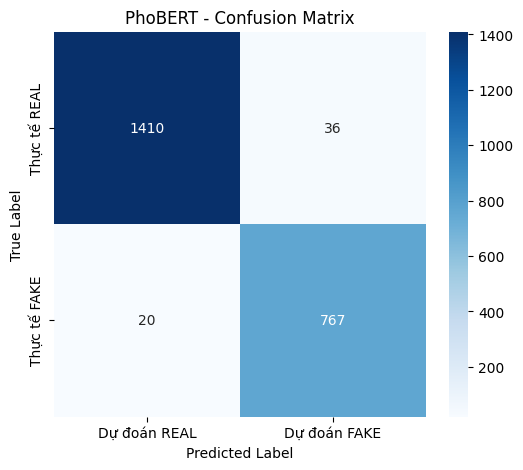

In [13]:
# 13. CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Dự đoán REAL", "Dự đoán FAKE"],
    yticklabels=["Thực tế REAL", "Thực tế FAKE"]
)
plt.title("PhoBERT - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

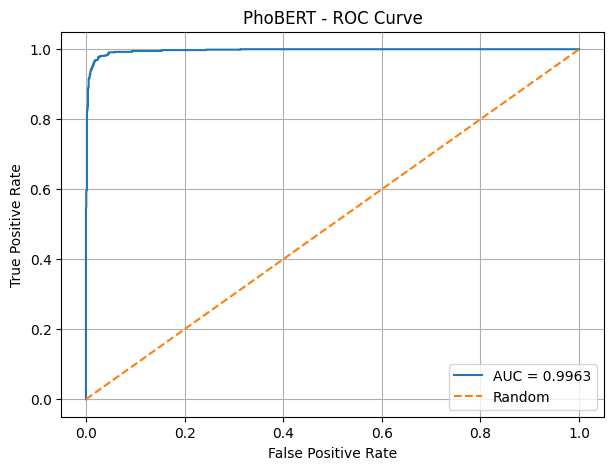

In [14]:
# 14. ROC CURVE

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("PhoBERT - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [15]:
# 15. HIỂN THỊ MỘT SỐ MẪU DỰ ĐOÁN SAI

test_text_df = pd.read_csv(test_path)

error_df = test_text_df.copy()
error_df["true_label_id"] = y_true
error_df["pred_label_id"] = y_pred
error_df["prob_fake"] = y_prob
error_df["true_label"] = error_df["true_label_id"].map(id2label)
error_df["pred_label"] = error_df["pred_label_id"].map(id2label)

wrong_df = error_df[error_df["true_label_id"] != error_df["pred_label_id"]]

print("\nSố mẫu dự đoán sai:", len(wrong_df))

display(
    wrong_df[
        ["text", "true_label", "pred_label", "prob_fake"]
    ].head(10)
)


Số mẫu dự đoán sai: 56


,text,true_label,pred_label,prob_fake
2,Mạng xã hội không thể phủi trách nhiệm việc ph...,FAKE,REAL,0.002241
59,Đã có năm thử nghiệm ngẫu nhiên được kiểm soát...,REAL,FAKE,0.999790
65,Chính phủ Thượng Hải chính thức khuyến cáo Vit...,FAKE,REAL,0.000108
152,CDC khuyến cáo nam giới nên cạo râu để bảo vệ ...,FAKE,REAL,0.000155
160,MoMo bác tin đồn liên quan đến sự cố bảo trì m...,FAKE,REAL,0.001356
181,Nghiên cứu quân sự cho biết vắc-xin cúm làm tă...,FAKE,REAL,0.002028
214,"Làm thế nào để phẫu thuật thẩm mỹ an toàn, bền...",REAL,FAKE,0.999023
238,"Chỉ sau cơn đau âm ỉ, người đàn ông tuyệt vọng...",FAKE,REAL,0.041850
242,Tại sao nước gạo tốt cho da? Nước gạo có thể d...,REAL,FAKE,0.999742
328,Thư từ biên tập viên: Một tuần của sự thật cay...,REAL,FAKE,0.988921


In [16]:
save_path = "./phobert_fake_news_final"

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print("Đã lưu model tại:", save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Đã lưu model tại: ./phobert_fake_news_final


In [17]:
# DEMO PREDICT TEXT MỚI

def predict_news(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH
    )

    device = model.device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]

    real_prob = probs[0].item()
    fake_prob = probs[1].item()

    pred_id = int(torch.argmax(probs).item())
    pred_label = id2label[pred_id]

    print("=" * 80)
    print("TEXT:")
    print(text)
    print("-" * 80)
    print(f"Kết quả dự đoán: {pred_label}")
    print(f"REAL: {real_prob * 100:.2f}%")
    print(f"FAKE: {fake_prob * 100:.2f}%")

    return {
        "text": text,
        "prediction": pred_label,
        "real_prob": real_prob,
        "fake_prob": fake_prob
    }

In [22]:
predict_news("WHO xác nhận vaccine COVID-19 an toàn và hiệu quả.")

TEXT:
WHO xác nhận vaccine COVID-19 an toàn và hiệu quả.
--------------------------------------------------------------------------------
Kết quả dự đoán: REAL
REAL: 99.99%
FAKE: 0.01%


{'text': 'WHO xác nhận vaccine COVID-19 an toàn và hiệu quả.',
 'prediction': 'REAL',
 'real_prob': 0.9998735189437866,
 'fake_prob': 0.00012642043293453753}

In [21]:
predict_news("Một bài viết trên mạng xã hội lan truyền thông tin rằng uống nước chanh mỗi sáng có thể chữa khỏi ung thư 100% mà không cần hóa trị, xạ trị hay điều trị y tế. Nội dung này không dẫn nguồn khoa học, không có bằng chứng y khoa và có dấu hiệu gây hiểu lầm nghiêm trọng về sức khỏe.")

TEXT:
Một bài viết trên mạng xã hội lan truyền thông tin rằng uống nước chanh mỗi sáng có thể chữa khỏi ung thư 100% mà không cần hóa trị, xạ trị hay điều trị y tế. Nội dung này không dẫn nguồn khoa học, không có bằng chứng y khoa và có dấu hiệu gây hiểu lầm nghiêm trọng về sức khỏe.
--------------------------------------------------------------------------------
Kết quả dự đoán: FAKE
REAL: 0.02%
FAKE: 99.98%


{'text': 'Một bài viết trên mạng xã hội lan truyền thông tin rằng uống nước chanh mỗi sáng có thể chữa khỏi ung thư 100% mà không cần hóa trị, xạ trị hay điều trị y tế. Nội dung này không dẫn nguồn khoa học, không có bằng chứng y khoa và có dấu hiệu gây hiểu lầm nghiêm trọng về sức khỏe.',
 'prediction': 'FAKE',
 'real_prob': 0.00016304907330777496,
 'fake_prob': 0.9998369216918945}